# Is our demand unpredictability silently breaking our supply chain?
### During high-volatility months, does our forecasting collapse — and drag delivery performance with it?

###  Load Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import calendar

### Load Data

In [2]:
df = pd.read_csv('data/dataset.csv')

# Step 1 : Map Volatility Across the Year

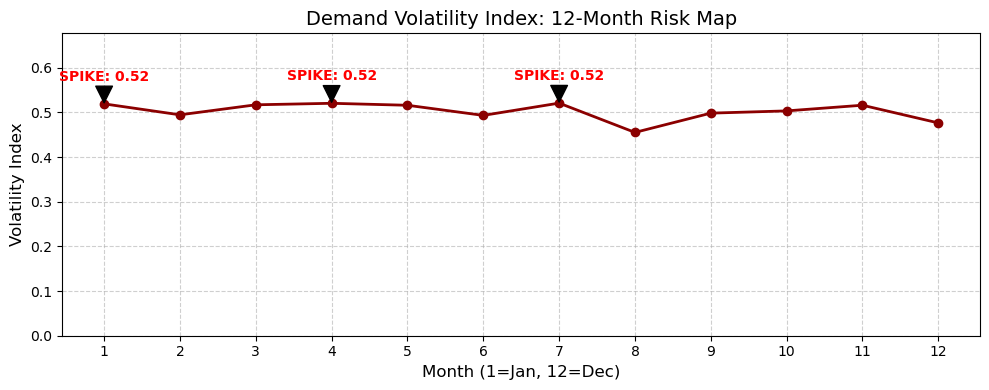

--- CRITICAL VOLATILITY ANALYSIS ---
Baseline Threshold: 0.52

The following months have been identified as 'Problem Months':
• January    | Volatility Index: 0.52 (CRITICAL)
• April      | Volatility Index: 0.52 (CRITICAL)
• July       | Volatility Index: 0.52 (CRITICAL)
------------------------------------


In [4]:
volatility_trend = df.groupby('temporal_month')['demand_volatility_index'].mean().sort_index()

plt.figure(figsize=(10, 4))
plt.plot(volatility_trend.index, volatility_trend.values, 
         marker='o', linestyle='-', color='darkred', linewidth=2)

threshold = volatility_trend.quantile(0.75)
spikes = volatility_trend[volatility_trend >= threshold]

# Annotation for spikes

[plt.annotate(f'SPIKE: {v:.2f}', xy=(m, v), xytext=(m, v + (v * 0.1)),
              arrowprops=dict(facecolor='black', shrink=0.05, width=1),
              ha='center', fontweight='bold', color='red') 
 for m, v in spikes.items()]

# 4. Formatting for the Boardroom
plt.title('Demand Volatility Index: 12-Month Risk Map', fontsize=14)
plt.xlabel('Month (1=Jan, 12=Dec)', fontsize=12)
plt.ylabel('Volatility Index', fontsize=12)
plt.xticks(range(1, 13)) # Ensure all 12 months show on the axis
plt.grid(True, linestyle='--', alpha=0.6)
plt.ylim(0, volatility_trend.max() * 1.3) # Give room for annotations

plt.tight_layout()
plt.show()

print("--- CRITICAL VOLATILITY ANALYSIS ---")
print(f"Baseline Threshold: {threshold:.2f}\n")

if not spikes.empty:
    print("The following months have been identified as 'Problem Months':")
    for month, value in spikes.items():
        month_name = calendar.month_name[int(month)]
        
        print(f"• {month_name:10} | Volatility Index: {value:.2f} (CRITICAL)")
else:
    print("No significant volatility spikes detected based on current thresholds.")

print("-" * 36)

#### Key Takeways : Three predictable spike months — not random chaos. We can plan for them.


# Step 2 Layer in Seasonality

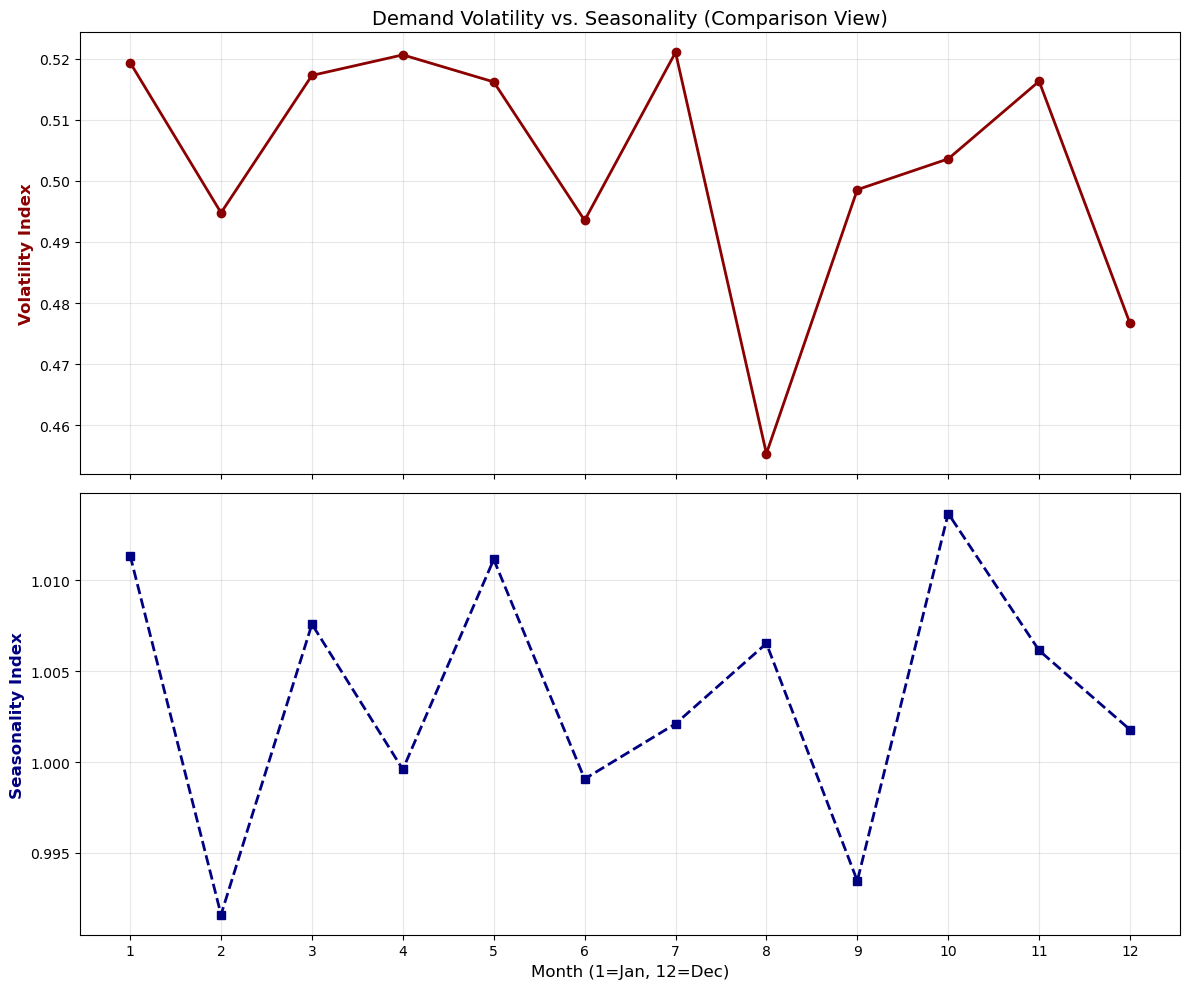

Note : Seasonality tells you when your business naturally grows and shrinks based on the calendar. 
 It is the historical "rhythm" of your demand.
Volatility tells you how unstable or "jittery" your demand is right now. 
 It measures the gap between what actually happened and what is considered "normal."


In [4]:

# 1. Prepare the data
trend_data = df.groupby('temporal_month')[['demand_volatility_index', 'seasonality_index']].mean().sort_index()

# 2. Create two subplots (2 rows, 1 column)
# sharex=True ensures both plots use the exact same x-axis alignment
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

# --- Top Plot: Volatility ---
ax1.plot(trend_data.index, trend_data['demand_volatility_index'], 
         marker='o', color='darkred', linewidth=2)
ax1.set_ylabel('Volatility Index', fontsize=12, fontweight='bold', color='darkred')
ax1.set_title('Demand Volatility vs. Seasonality (Comparison View)', fontsize=14)
ax1.grid(True, alpha=0.3)

# --- Bottom Plot: Seasonality ---
ax2.plot(trend_data.index, trend_data['seasonality_index'], 
         marker='s', linestyle='--', color='navy', linewidth=2)
ax2.set_ylabel('Seasonality Index', fontsize=12, fontweight='bold', color='navy')
ax2.set_xlabel('Month (1=Jan, 12=Dec)', fontsize=12)
ax2.grid(True, alpha=0.3)

# 3. Formatting
plt.xticks(range(1, 13))

# Tight_layout prevents the labels of the bottom plot from overlapping the top one
plt.tight_layout()
plt.show()

print('Note : Seasonality tells you when your business naturally grows and shrinks based on the calendar. \n It is the historical "rhythm" of your demand.')
print('Volatility tells you how unstable or "jittery" your demand is right now. \n It measures the gap between what actually happened and what is considered "normal."')

#### Key Takeways : Our volatility is not seasonal — it's structural. Budgeting by season won't fix it.


# Step 3 : Does Forecasting Break underpressure? 

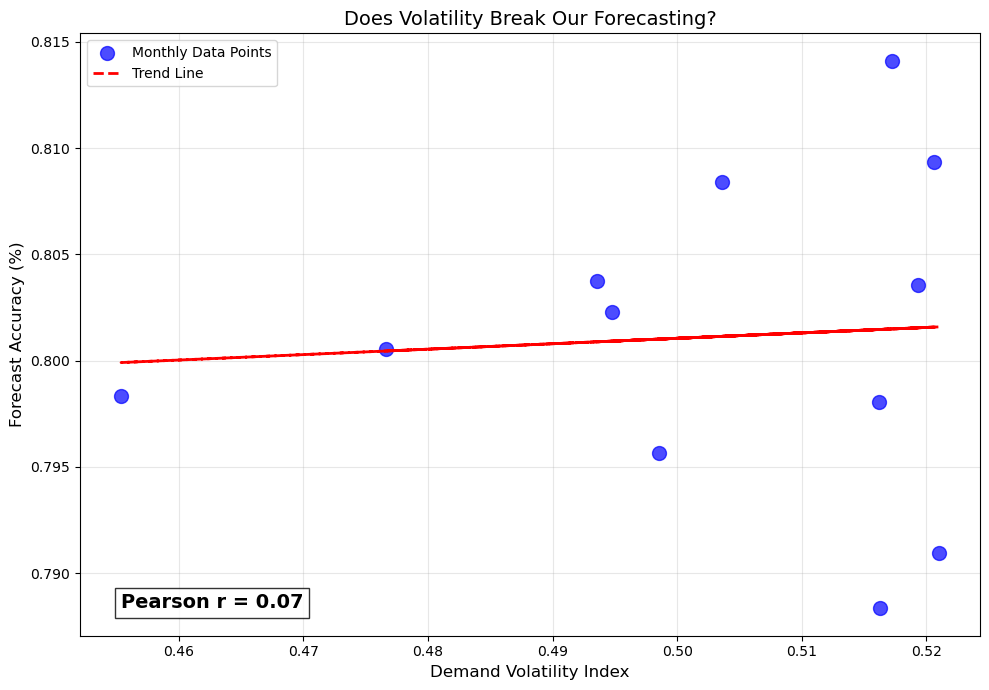

Correlation Analysis: The Pearson r is 0.07
CONCLUSION: Weak Correlation. Other factors besides volatility are driving forecast errors.


In [ ]:
# We need the relationship between volatility and accuracy per month
monthly_stats = df.groupby('temporal_month')[['demand_volatility_index', 'forecast_accuracy']].mean().sort_index()

x = monthly_stats['demand_volatility_index']
y = monthly_stats['forecast_accuracy']

# 2. Calculate Pearson Correlation Coefficient (r) using NumPy
correlation_matrix = np.corrcoef(x, y)
pearson_r = correlation_matrix[0, 1]

# 3. Calculate the Trend Line (Linear Regression)
slope, intercept = np.polyfit(x, y, 1)
trendline = slope * x + intercept

# 4. Create the Visualization
plt.figure(figsize=(10, 7))

# Plot the individual months as dots
plt.scatter(x, y, color='blue', s=100, alpha=0.7, label='Monthly Data Points')

# Plot the Regression Trend Line
plt.plot(x, trendline, color='red', linestyle='--', linewidth=2, label='Trend Line')

# 5. Add Annotations for the Boardroom
plt.text(x.min(), y.min(), f'Pearson r = {pearson_r:.2f}', 
         fontsize=14, fontweight='bold', bbox=dict(facecolor='white', alpha=0.8))

plt.title('Does Volatility Break Our Forecasting?', fontsize=14)
plt.xlabel('Demand Volatility Index', fontsize=12)
plt.ylabel('Forecast Accuracy (%)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

# 6. Strategic Print Statement
print(f"Correlation Analysis: The Pearson r is {pearson_r:.2f}")
if pearson_r < -0.7:
    print("CONCLUSION: Strong Negative Correlation. Volatility is severely damaging our planning accuracy.")
elif pearson_r < -0.4:
    print("CONCLUSION: Moderate Negative Correlation. Volatility is a significant factor in forecast errors.")
else:
    print("CONCLUSION: Weak Correlation. Other factors besides volatility are driving forecast errors.")

#### Key Takeways : Forecast errors have other root causes — look at data quality, SKU mix, or planning models — not volatility.


# Step 4 : Volume Behavior During Volatile Months

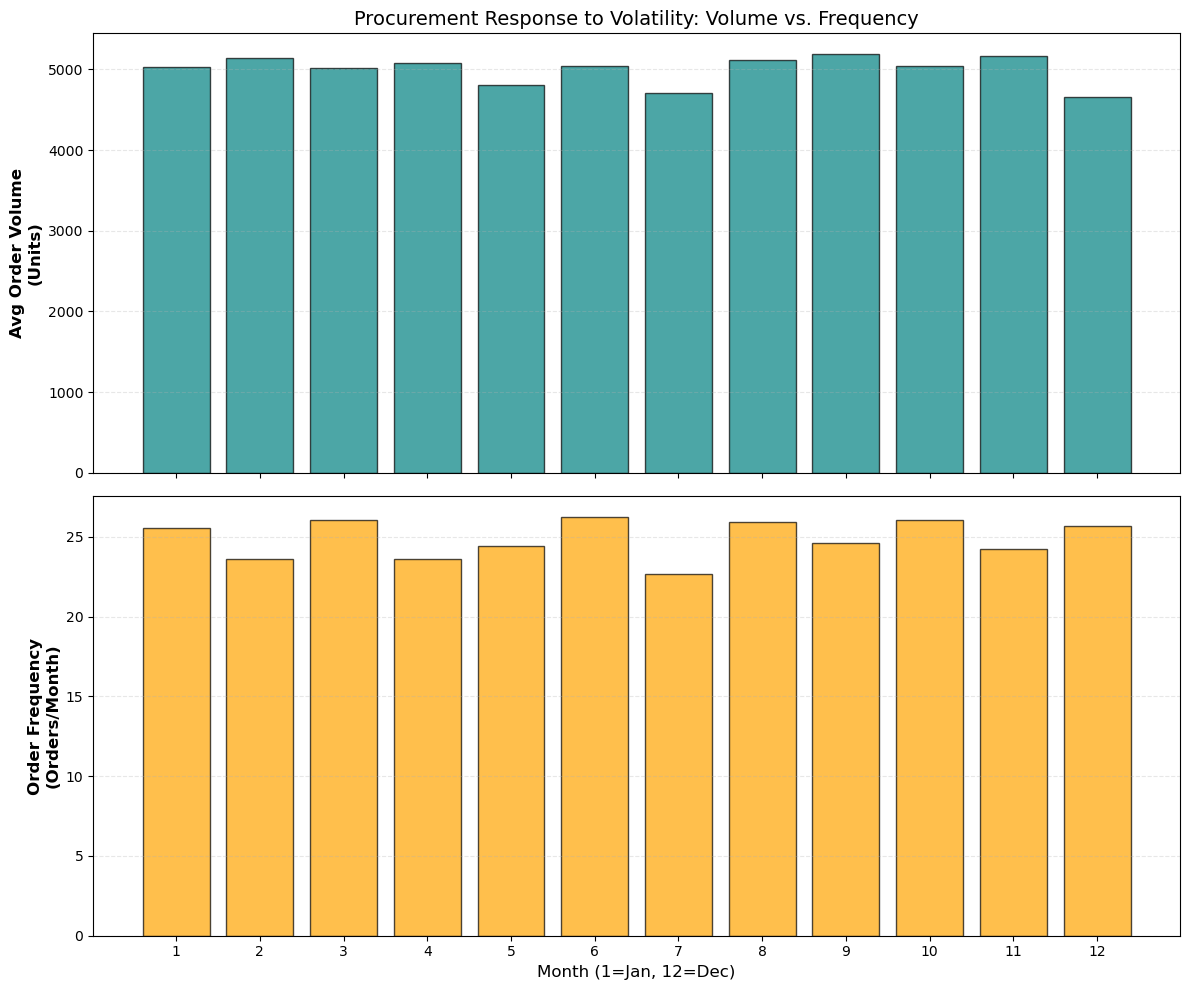

In [6]:

order_behavior = df.groupby('temporal_month')[['avg_order_volume', 'order_frequency_monthly']].mean().sort_index()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

# --- Top Plot: Order Volume ---
ax1.bar(order_behavior.index, order_behavior['avg_order_volume'], 
        color='teal', alpha=0.7, edgecolor='black')
ax1.set_ylabel('Avg Order Volume\n(Units)', fontsize=12, fontweight='bold')
ax1.set_title('Procurement Response to Volatility: Volume vs. Frequency', fontsize=14)
ax1.grid(axis='y', linestyle='--', alpha=0.3)

# --- Bottom Plot: Order Frequency ---
ax2.bar(order_behavior.index, order_behavior['order_frequency_monthly'], 
        color='orange', alpha=0.7, edgecolor='black')

ax2.set_ylabel('Order Frequency\n(Orders/Month)', fontsize=12, fontweight='bold')
ax2.set_xlabel('Month (1=Jan, 12=Dec)', fontsize=12)
ax2.grid(axis='y', linestyle='--', alpha=0.3)

# 3. Formatting
plt.xticks(range(1, 13))

plt.tight_layout()
plt.show()

#### Key Takeway : Procurement is well-disciplined 

# Step 5 : Delivery Consequences of Demand Chaos

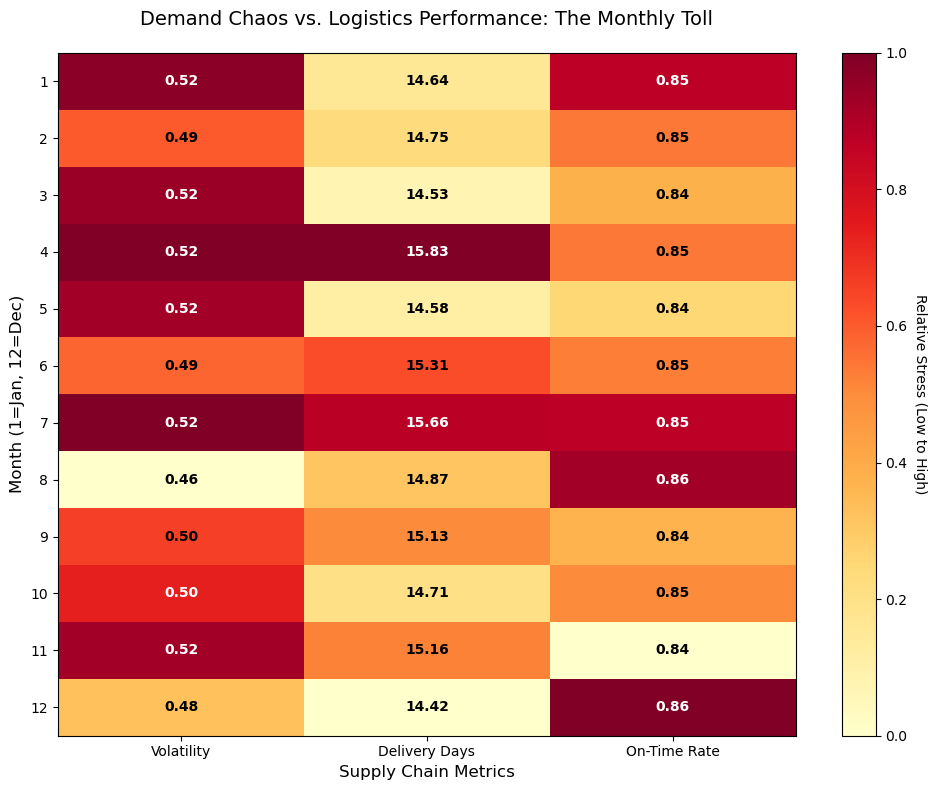

In [6]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Prepare and Aggregate the Data
cols = ['demand_volatility_index', 'delivery_time_days', 'on_time_delivery_rate']
heatmap_data = df.groupby('temporal_month')[cols].mean().sort_index()

# 2. Normalize the data (0 to 1 scale)
# This is crucial so that "Days" and "Index" values share the same color intensity
data_min = heatmap_data.min()
data_max = heatmap_data.max()
heatmap_norm = (heatmap_data - data_min) / (data_max - data_min)

# 3. Create the Heatmap
fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(heatmap_norm, cmap='YlOrRd', aspect='auto')

# 4. Add the Text Annotations (The "Manual" way)
# We loop through every row (month) and column (metric) to place the raw numbers
for i in range(len(heatmap_data.index)):
    for j in range(len(cols)):
        val = heatmap_data.iloc[i, j]
        # We change text color to white for dark backgrounds (high values) for readability
        color = "white" if heatmap_norm.iloc[i, j] > 0.7 else "black"
        ax.text(j, i, f'{val:.2f}', ha="center", va="center", color=color, fontweight='bold')

# 5. Formatting the Axes
ax.set_xticks(np.arange(len(cols)))
ax.set_xticklabels(['Volatility', 'Delivery Days', 'On-Time Rate'])
ax.set_yticks(np.arange(len(heatmap_data.index)))
ax.set_yticklabels(heatmap_data.index)

plt.title('Demand Chaos vs. Logistics Performance: The Monthly Toll', fontsize=14, pad=20)
plt.xlabel('Supply Chain Metrics', fontsize=12)
plt.ylabel('Month (1=Jan, 12=Dec)', fontsize=12)

# Add a colorbar to show the scale
cbar = ax.figure.colorbar(im, ax=ax)
cbar.ax.set_ylabel("Relative Stress (Low to High)", rotation=-90, va="bottom")

plt.tight_layout()
plt.show()

#### Key Takeway : Logistics is resilient — but April is a structural bottleneck needing targeted investment.


# Step 6 : Volatility Distribution Deep Dive

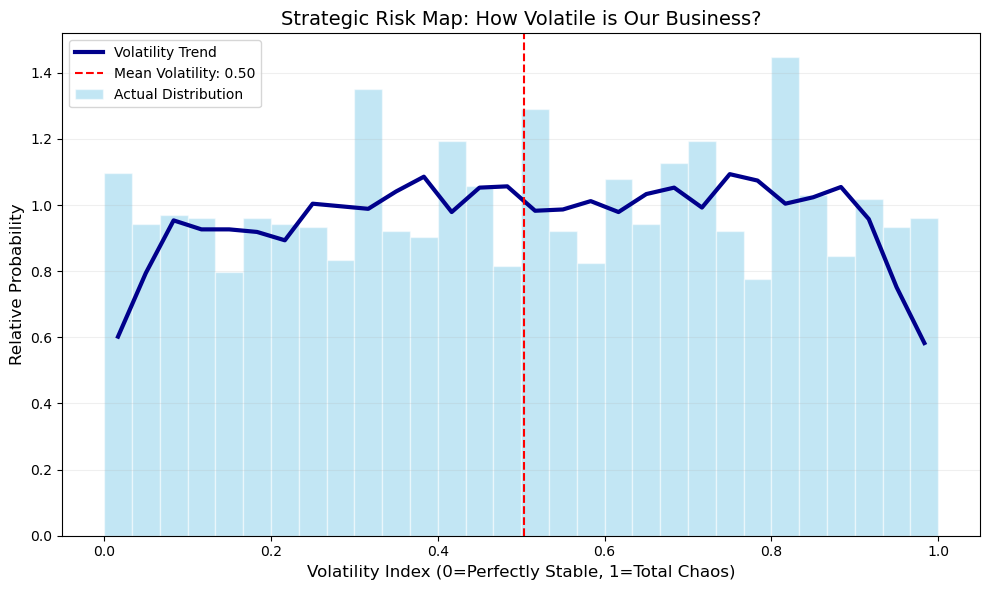

In [7]:
data = df['demand_volatility_index'].dropna().values

counts, bin_edges = np.histogram(data, bins=30, density=True)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

window_size = 5
smoothed_counts = np.convolve(counts, np.ones(window_size)/window_size, mode='same')

# 4. Create the Visualization
plt.figure(figsize=(10, 6))

# Plot the Histogram
plt.bar(bin_centers, counts, width=(bin_edges[1]-bin_edges[0]), 
        color='skyblue', alpha=0.5, edgecolor='white', label='Actual Distribution')

# Plot the Smoothed "Trend" Line
plt.plot(bin_centers, smoothed_counts, color='darkblue', linewidth=3, label='Volatility Trend')

# 5. Add Statistical Benchmarks
mean_val = np.mean(data)
plt.axvline(mean_val, color='red', linestyle='--', label=f'Mean Volatility: {mean_val:.2f}')

# 6. Formatting for the CEO
plt.title('Strategic Risk Map: How Volatile is Our Business?', fontsize=14)
plt.xlabel('Volatility Index (0=Perfectly Stable, 1=Total Chaos)', fontsize=12)
plt.ylabel('Relative Probability', fontsize=12)
plt.legend()
plt.grid(axis='y', alpha=0.2)

plt.tight_layout()
plt.show()

#### Key TAkeway : Volatility is our baseline — not an exception. Structural solutions required, not reactive ones.


# Step 7 : The Narrative Summary Table

In [8]:
# 1. Consolidate all key metrics by month
# We calculate the mean for each KPI to get the "Monthly Profile"
boardroom_summary = df.groupby('temporal_month').agg({
    'demand_volatility_index': 'mean',
    'forecast_accuracy': 'mean',
    'avg_order_volume': 'mean',
    'on_time_delivery_rate': 'mean'
}).sort_index()

# 2. Apply "Boardroom Styling"
# We use a background gradient for Volatility (Red = High Chaos)
# and a different gradient for Accuracy/On-Time (Green = High Success)
styled_table = boardroom_summary.style\
    .background_gradient(subset=['demand_volatility_index'], cmap='Reds')\
    .background_gradient(subset=['forecast_accuracy', 'on_time_delivery_rate'], cmap='RdYlGn')\
    .format({
        'demand_volatility_index': '{:.2f}',
        'forecast_accuracy': '{:.1%}',
        'avg_order_volume': '{:,.0f}',
        'on_time_delivery_rate': '{:.1%}'
    })\
    .set_caption("Q2 Supply Chain Performance: The Seasonal Story")\
    .set_table_styles([{
        'selector': 'th',
        'props': [('font-size', '12pt'), ('background-color', '#f4f4f4')]
    }])

# 3. Display the Table
# Note: In a Jupyter Notebook, simply typing 'styled_table' renders the HTML.
# To save it as an image or HTML file:
# styled_table.to_html('boardroom_summary.html')

styled_table

,demand_volatility_index,forecast_accuracy,avg_order_volume,on_time_delivery_rate
temporal_month,,,,
1,0.52,80.4%,"5,029",85.5%
2,0.49,80.2%,"5,139",84.8%
3,0.52,81.4%,"5,014",84.5%
4,0.52,80.9%,"5,076",84.8%
5,0.52,79.8%,"4,812",84.2%
6,0.49,80.4%,"5,045",84.8%
7,0.52,79.1%,"4,711",85.5%
8,0.46,79.8%,"5,120",85.6%
9,0.50,79.6%,"5,189",84.5%
